<a href="https://colab.research.google.com/github/adeleke1508/Ismail_Khaleed_3/blob/main/kmeans_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import robust_scale, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/drive/MyDrive/content_refresh_anonymized.csv')
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [5]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')

In [6]:
sample_df = df[['ctr', 'impressions_90d', 'clicks_90d']]
sample_df

,ctr,impressions_90d,clicks_90d
0,0.76,3803,29
1,0.05,15320,7
2,0.09,12581,11
3,0.49,11751,58
4,0.13,19140,24
...,...,...,...
29995,0.00,1,0
29996,0.39,761,3
29997,0.19,6336,12
29998,0.22,154763,340


In [7]:
sample_df_imp_corr = sample_df['impressions_90d'].corr(sample_df['ctr'])
sample_df_clk_corr = sample_df['clicks_90d'].corr(sample_df['ctr'])
print(sample_df_imp_corr)
print(sample_df_clk_corr)

-0.01894973657977031
0.010608834300972191


In [8]:
sample_1_idx = sample_df['impressions_90d'] <50
sample_1 = sample_df.loc[sample_1_idx]
sample_1

,ctr,impressions_90d,clicks_90d
6,0.00,20,0
11,0.00,1,0
15,23.68,38,9
25,0.00,27,0
29,0.00,19,0
...,...,...,...
29981,0.00,3,0
29987,0.00,34,0
29988,0.00,2,0
29992,0.00,1,0


In [9]:
sample_1_imp_corr = sample_1['impressions_90d'].corr(sample_1['ctr'])
sample_1_clk_corr = sample_1['clicks_90d'].corr(sample_1['ctr'])
print(sample_1_imp_corr)
print(sample_1_clk_corr)

-0.0641527765895553
0.5348680159114783


In [10]:
sample_2_idx = sample_1['ctr'] > 5
sample_2 = sample_1.loc[sample_2_idx]
sample_2

,ctr,impressions_90d,clicks_90d
15,23.68,38,9
61,11.11,9,1
91,5.26,38,2
116,15.38,13,2
117,14.29,7,1
...,...,...,...
29404,16.67,6,1
29457,6.12,49,3
29538,7.14,28,2
29647,40.00,5,2


In [11]:
sample_2_imp_corr = sample_2['impressions_90d'].corr(sample_2['ctr'])
sample_2_clk_corr = sample_2['clicks_90d'].corr(sample_2['ctr'])
print(sample_2_imp_corr)
print(sample_2_clk_corr)

-0.5211574594837994
-0.03503851564659326


In [12]:
corr_compare = []
corr_compare.append({
    'sample_df_imp_corr': sample_df_imp_corr,
    'sample_df_clk_corr': sample_df_clk_corr,
    'sample_1_imp_corr': sample_1_imp_corr,
    'sample_1_clk_corr': sample_1_clk_corr,
    'sample_2_imp_corr': sample_2_imp_corr,
    'sample_2_clk_corr': sample_2_clk_corr
})
corr_df = pd.DataFrame(corr_compare)
corr_df

,sample_df_imp_corr,sample_df_clk_corr,sample_1_imp_corr,sample_1_clk_corr,sample_2_imp_corr,sample_2_clk_corr
0,-0.01895,0.010609,-0.064153,0.534868,-0.521157,-0.035039


In [13]:
sample_df_2 = df[['word_count', 'impressions_90d']]
sample_df_2

,word_count,impressions_90d
0,3221.0,3803
1,2481.0,15320
2,3515.0,12581
3,NaN,11751
4,2803.0,19140
...,...,...
29995,1386.0,1
29996,2654.0,761
29997,2857.0,6336
29998,NaN,154763


In [14]:
sample_3 = sample_df_2.loc[sample_df_2['word_count'].isna()]
sample_3

,word_count,impressions_90d
3,NaN,11751
7,NaN,1724
9,NaN,1240
10,NaN,20919
17,NaN,9449
...,...,...
29983,NaN,2845
29986,NaN,491
29989,NaN,29760
29993,NaN,410


In [15]:
(sample_3['impressions_90d']>1000).value_counts()

,count
impressions_90d,
False,4041
True,3658


In [16]:
sample_3.describe()

,word_count,impressions_90d
count,0.0,7699.000000
mean,NaN,5552.991817
std,NaN,18988.269171
min,NaN,1.000000
25%,NaN,237.000000
50%,NaN,878.000000
75%,NaN,3256.500000
max,NaN,517715.000000


In [17]:
sample_df_3 = df[['word_count', 'content_type']]
sample_df_4 = df[['word_count', 'content_age_days']]

In [18]:
sample_df_3

,word_count,content_type
0,3221.0,keyword article
1,2481.0,keyword article
2,3515.0,keyword article
3,NaN,keyword article
4,2803.0,keyword article
...,...,...
29995,1386.0,keyword article
29996,2654.0,keyword article
29997,2857.0,keyword article
29998,NaN,keyword article


In [19]:
sample_4 = sample_df_3.loc[sample_df_3['word_count'].isna()]
sample_4

,word_count,content_type
3,NaN,keyword article
7,NaN,keyword article
9,NaN,keyword article
10,NaN,keyword article
17,NaN,keyword article
...,...,...
29983,NaN,keyword article
29986,NaN,keyword article
29989,NaN,keyword article
29993,NaN,keyword article


In [20]:
(df['content_type']=='keyword article').value_counts()

,count
content_type,
True,27207
False,2793


In [21]:
(sample_4['content_type']=='keyword article').value_counts()

,count
content_type,
True,7699


In [22]:
sample_5 = sample_df_3.loc[sample_df_3['content_type']=='keyword article'].dropna()
sample_5

,word_count,content_type
0,3221.0,keyword article
1,2481.0,keyword article
2,3515.0,keyword article
4,2803.0,keyword article
5,3080.0,keyword article
...,...,...
29994,2801.0,keyword article
29995,1386.0,keyword article
29996,2654.0,keyword article
29997,2857.0,keyword article


In [23]:
sample_5.describe()

,word_count
count,19508.000000
mean,3215.507689
std,1419.156637
min,424.000000
25%,2529.000000
50%,2902.000000
75%,3621.000000
max,9546.000000


Given the word_count with missing values, are simply pages with unrecorded values and all of them are of the content type = 'keyword article', my assumptions are:

1.what if i replace them with the median of the rows with content_type='keyword article', which is 2902.

Conclusion, I will create a new binary column 'old_with_missing_values'which will be 1 when word_count and search volume are missing  and content_age_days > 120, then i will add the column to the features to be clustered , then i will replace the missing word_counts with the media of the pages whose content_type = 'keyword_article'

In [24]:
sample_6 = sample_df_4.loc[sample_df_4['word_count'].isna()]
sample_6

,word_count,content_age_days
3,NaN,463
7,NaN,445
9,NaN,257
10,NaN,329
17,NaN,421
...,...,...
29983,NaN,330
29986,NaN,445
29989,NaN,148
29993,NaN,441


In [25]:
sample_6.describe()

,word_count,content_age_days
count,0.0,7699.000000
mean,NaN,392.562670
std,NaN,101.814269
min,NaN,141.000000
25%,NaN,329.000000
50%,NaN,438.000000
75%,NaN,466.000000
max,NaN,564.000000


In [26]:
sample_df_5 = df[['search_volume', 'impressions_90d', 'content_type', 'content_age_days']]
sample_df_5

,search_volume,impressions_90d,content_type,content_age_days
0,10.0,3803,keyword article,187
1,90.0,15320,keyword article,445
2,0.0,12581,keyword article,141
3,10.0,11751,keyword article,463
4,0.0,19140,keyword article,263
...,...,...,...,...
29995,10.0,1,keyword article,347
29996,0.0,761,keyword article,96
29997,10.0,6336,keyword article,124
29998,10.0,154763,keyword article,466


In [27]:
sample_7 = sample_df_5.loc[sample_df_5['search_volume'].isna()]
sample_7

,search_volume,impressions_90d,content_type,content_age_days
11,NaN,1,feedly article,312
61,NaN,9,feedly article,130
67,NaN,32,feedly article,91
71,NaN,3,feedly article,288
91,NaN,38,keyword article,305
...,...,...,...,...
29919,NaN,3,feedly article,119
29965,NaN,3,feedly article,128
29971,NaN,3,feedly article,111
29973,NaN,2,feedly article,290


In [28]:
sample_7.describe()

,search_volume,impressions_90d,content_age_days
count,0.0,2468.000000,2468.000000
mean,NaN,501.106159,277.037277
std,NaN,2985.248782,115.270751
min,NaN,1.000000,90.000000
25%,NaN,3.000000,138.000000
50%,NaN,6.000000,296.000000
75%,NaN,76.250000,315.000000
max,NaN,61832.000000,557.000000


In [29]:
(sample_7['content_type']).unique()

array(['feedly article', 'keyword article'], dtype=object)

In [30]:
(df['content_type']).unique()

array(['keyword article', 'feedly article', 'comparison article'],
      dtype=object)

In [31]:
(sample_7['content_type']=='keyword article').value_counts()

,count
content_type,
False,2096
True,372


In [32]:
(sample_7['content_type']=='feedly article').value_counts()

,count
content_type,
True,2096
False,372


In [33]:
sample_8 = sample_df_5.loc[sample_df_5['content_type']=='feedly article']
sample_8

,search_volume,impressions_90d,content_type,content_age_days
11,NaN,1,feedly article,312
61,NaN,9,feedly article,130
67,NaN,32,feedly article,91
71,NaN,3,feedly article,288
116,NaN,13,feedly article,298
...,...,...,...,...
29919,NaN,3,feedly article,119
29965,NaN,3,feedly article,128
29971,NaN,3,feedly article,111
29973,NaN,2,feedly article,290


In [34]:
sample_9 = sample_7.loc[sample_7['content_type']=='keyword article']
sample_9.describe()

,search_volume,impressions_90d,content_age_days
count,0.0,372.000000,372.000000
mean,NaN,2261.720430,448.223118
std,NaN,7123.562873,98.171538
min,NaN,1.000000,112.000000
25%,NaN,11.000000,313.000000
50%,NaN,177.500000,504.000000
75%,NaN,1015.000000,517.000000
max,NaN,61832.000000,557.000000


In [35]:
features = ['impressions_90d', 'clicks_90d', 'ctr', 'word_count', 'search_volume']
X = df[features].copy().replace([np.inf, -np.inf], np.nan).dropna()
X_log = np.log1p(X)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)

In [36]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster = kmeans.fit_predict(X_scaled)

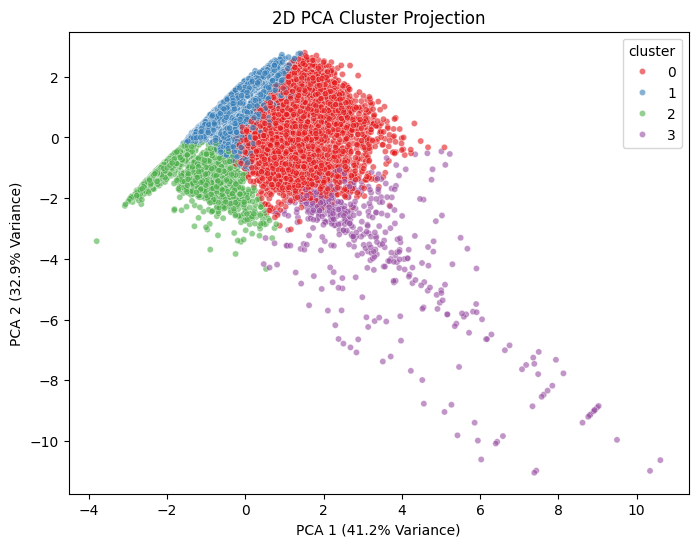

In [37]:
df_clean = df.loc[X.index].copy()
df_clean['cluster'] = cluster
pca = PCA(n_components=2)
pca_cords = pca.fit_transform(X_scaled)
df_clean['pca_1'] = pca_cords[:, 0]
df_clean['pca_2'] = pca_cords[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    palette='Set1',
    alpha=0.6,
    s = 20
)
plt.title('2D PCA Cluster Projection')
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
plt.show()

In [38]:
print(f'Silhouette Score: {silhouette_score(X_scaled, cluster):.4f}')
print(f'Davies Bouldins Score: {davies_bouldin_score(X_scaled, cluster):.4f}')
print(f'Calinski Harabasz Score: {calinski_harabasz_score(X_scaled, cluster):.4f}')

Silhouette Score: 0.2805
Davies Bouldins Score: 1.1752
Calinski Harabasz Score: 7090.7847


In [39]:
pd.crosstab(df_clean['cluster'], df_clean['content_type'], normalize='index') * 100


content_type,comparison article,keyword article
cluster,,
0,0.581934,99.418066
1,7.155163,92.844837
2,0.274725,99.725275
3,4.430380,95.569620


In [40]:
pd.crosstab(df_clean['cluster'], df_clean['trend_direction'], normalize='index') * 100

trend_direction,down,flat,new,stable,up
cluster,,,,,
0,57.598201,0.079355,0.978707,26.663140,14.680598
1,63.787757,5.558746,6.305272,12.828758,11.519467
2,57.356532,11.233211,13.949939,8.669109,8.791209
3,47.890295,5.485232,8.649789,16.244726,21.729958


In [41]:
cluster_names = {
    0: 'Pillar Staples',
    1: 'Decaying Giants',
    2: 'Emerging / Short Form',
    3: 'Rising Star'
}

df_clean['cluster_names'] = df_clean['cluster'].map(cluster_names)

In [42]:
df_clean

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,cluster,pca_1,pca_2,cluster_names
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,4.55,0.00,good,striking,down,-41.4,0,1.503825,-0.754770,Pillar Staples
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,10.00,0.00,good,page_3_5,down,-57.7,0,-0.363766,-0.071065,Pillar Staples
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,28.57,0.00,good,page_3_5,down,-60.9,0,0.491217,0.726377,Pillar Staples
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,24.29,0.00,good,page_3_5,down,-34.7,0,0.387326,0.177233,Pillar Staples
5,content_d4084a4bc775,client_f369cb89fc,720.0,1.00,HIGH,1.05,keyword article,transactional,3080.0,18178.0,...,25.00,0.00,good,page_1,down,-38.9,1,-0.495091,0.318748,Decaying Giants
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,content_995627a1f490,client_7f2253d7e2,70.0,0.05,LOW,0.00,keyword article,transactional,2801.0,18452.0,...,16.67,0.00,moderate,page_1,down,-65.8,0,0.851092,-1.262395,Pillar Staples
29995,content_c322796023c8,client_e29c9c180c,10.0,0.05,LOW,0.00,keyword article,transactional,1386.0,9084.0,...,0.00,0.00,low,top_3,new,NaN,2,-2.308791,-1.197425,Emerging / Short Form
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,66.67,0.00,moderate,page_1,down,-75.1,0,0.282320,-0.465091,Pillar Staples
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,0.00,0.00,good,page_1,down,-66.2,0,0.255480,-0.025758,Pillar Staples


1. Cluster 0: "Pillar Staples" (or Core Performers)The Data: High Impressions ($6,079$), High Clicks ($15$), Long-form ($3,089$ words), high proportion of Stable traffic ($26.7\%$).Why this name? These are your heavy lifters driving the vast majority of organic visibility and traffic.Editorial Action: Protect & Maintain (Keep updated to prevent traffic decay).
2. Cluster 1: "Decaying Giants" (or Stagnant Long-form)The Data: High word count ($3,035$ words), but low impressions ($271$), $0$ clicks, and the highest rate of traffic decline ($63.8\%$ Down).Why this name? Significant effort went into creating these long articles, but they are losing search authority and failing to convert impressions into clicks.Editorial Action: SEO Audit & Refresh (Update search intent, fix technical indexation, or refresh keywords).
3. Cluster 2: "Emerging / Short-Form" (or Gaps & Stubs)The Data: Shortest word count ($1,479$ words), highest share of Brand New content ($14.0\%$) and highest Search Volume ($10$).Why this name? This segment represents newer articles that haven't fully matured yet, alongside thin/short-form content targeting competitive terms.Editorial Action: Expand & Consolidate (Give new articles time to rank, or expand thin content to compete).
4. Cluster 3: "Rising Stars" (or High-CTR Micro-Niches)The Data: Low impressions ($54.5$), high CTR ($2.5\%$), and the highest proportion of growing traffic ($21.7\%$ Up).Why this name? When people see this content, they click. Traffic is actively trending upward, even if current overall reach is still small.Editorial Action: Scale & Promote (Build internal links and boost distribution to expand impression reach).

In [43]:
new_df = df.copy()
new_df

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.00,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.00,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.00,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.00,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.00,good,page_3_5,down,-34.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,content_c322796023c8,client_e29c9c180c,10.0,0.05,LOW,0.00,keyword article,transactional,1386.0,9084.0,...,8000-15000,0.00,0.0,0.00,0.00,0.00,low,top_3,new,NaN
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,15000-25000,0.39,6.6,0.00,66.67,0.00,moderate,page_1,down,-75.1
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,15000-25000,0.19,4.1,0.00,0.00,0.00,good,page_1,down,-66.2
29998,content_ab26273a7e7a,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,transactional,NaN,NaN,...,NaN,0.22,6.0,1.73,4.06,0.00,excellent,page_1,down,-27.9


In [44]:
cond =  (new_df['word_count'].isna()) | (new_df['search_volume'].isna()) & (new_df['content_type']=='keyword article')
new_df['old_with_missing_values'] = cond.astype(int)
new_df

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,0.76,10.6,5.88,4.55,0.00,good,striking,down,-41.4,0
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.05,20.3,0.00,10.00,0.00,good,page_3_5,down,-57.7,0
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.09,36.5,0.00,28.57,0.00,good,page_3_5,down,-60.9,0
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,0.49,6.2,1.28,3.45,0.00,good,page_1,stable,-13.8,1
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.13,44.0,0.00,24.29,0.00,good,page_3_5,down,-34.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,content_c322796023c8,client_e29c9c180c,10.0,0.05,LOW,0.00,keyword article,transactional,1386.0,9084.0,...,0.00,0.0,0.00,0.00,0.00,low,top_3,new,NaN,0
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,0.39,6.6,0.00,66.67,0.00,moderate,page_1,down,-75.1,0
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,0.19,4.1,0.00,0.00,0.00,good,page_1,down,-66.2,0
29998,content_ab26273a7e7a,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,transactional,NaN,NaN,...,0.22,6.0,1.73,4.06,0.00,excellent,page_1,down,-27.9,1


In [45]:
new_df['word_count'] = new_df['word_count'].fillna(sample_5['word_count'].median())
new_df

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,0.76,10.6,5.88,4.55,0.00,good,striking,down,-41.4,0
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.05,20.3,0.00,10.00,0.00,good,page_3_5,down,-57.7,0
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.09,36.5,0.00,28.57,0.00,good,page_3_5,down,-60.9,0
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,2902.0,NaN,...,0.49,6.2,1.28,3.45,0.00,good,page_1,stable,-13.8,1
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.13,44.0,0.00,24.29,0.00,good,page_3_5,down,-34.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,content_c322796023c8,client_e29c9c180c,10.0,0.05,LOW,0.00,keyword article,transactional,1386.0,9084.0,...,0.00,0.0,0.00,0.00,0.00,low,top_3,new,NaN,0
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,0.39,6.6,0.00,66.67,0.00,moderate,page_1,down,-75.1,0
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,0.19,4.1,0.00,0.00,0.00,good,page_1,down,-66.2,0
29998,content_ab26273a7e7a,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,transactional,2902.0,NaN,...,0.22,6.0,1.73,4.06,0.00,excellent,page_1,down,-27.9,1


In [46]:
keyword_median = new_df.loc[new_df['content_type']=='keyword article', 'search_volume'].median()
mask = (new_df['content_type'] == 'keyword article') & (new_df['search_volume'].isna())
new_df.loc[mask, 'search_volume'] = keyword_median
new_df

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,0.76,10.6,5.88,4.55,0.00,good,striking,down,-41.4,0
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.05,20.3,0.00,10.00,0.00,good,page_3_5,down,-57.7,0
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.09,36.5,0.00,28.57,0.00,good,page_3_5,down,-60.9,0
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,2902.0,NaN,...,0.49,6.2,1.28,3.45,0.00,good,page_1,stable,-13.8,1
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.13,44.0,0.00,24.29,0.00,good,page_3_5,down,-34.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,content_c322796023c8,client_e29c9c180c,10.0,0.05,LOW,0.00,keyword article,transactional,1386.0,9084.0,...,0.00,0.0,0.00,0.00,0.00,low,top_3,new,NaN,0
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,0.39,6.6,0.00,66.67,0.00,moderate,page_1,down,-75.1,0
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,0.19,4.1,0.00,0.00,0.00,good,page_1,down,-66.2,0
29998,content_ab26273a7e7a,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,transactional,2902.0,NaN,...,0.22,6.0,1.73,4.06,0.00,excellent,page_1,down,-27.9,1


In [47]:
new_df['search_volume'] = new_df['search_volume'].fillna(0)
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   content_id               30000 non-null  object 
 1   client_id                30000 non-null  object 
 2   search_volume            30000 non-null  float64
 3   competition              27532 non-null  float64
 4   competition_level        27390 non-null  object 
 5   cpc                      27532 non-null  float64
 6   content_type             30000 non-null  object 
 7   main_intent              27626 non-null  object 
 8   word_count               30000 non-null  float64
 9   char_count               22301 non-null  float64
 10  provider_used            8562 non-null   object 
 11  model_used               24267 non-null  object 
 12  impressions_90d          30000 non-null  int64  
 13  clicks_90d               30000 non-null  int64  
 14  pageviews_90d         

In [48]:
new_df

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,0.76,10.6,5.88,4.55,0.00,good,striking,down,-41.4,0
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.05,20.3,0.00,10.00,0.00,good,page_3_5,down,-57.7,0
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.09,36.5,0.00,28.57,0.00,good,page_3_5,down,-60.9,0
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,2902.0,NaN,...,0.49,6.2,1.28,3.45,0.00,good,page_1,stable,-13.8,1
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.13,44.0,0.00,24.29,0.00,good,page_3_5,down,-34.7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,content_c322796023c8,client_e29c9c180c,10.0,0.05,LOW,0.00,keyword article,transactional,1386.0,9084.0,...,0.00,0.0,0.00,0.00,0.00,low,top_3,new,NaN,0
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,0.39,6.6,0.00,66.67,0.00,moderate,page_1,down,-75.1,0
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,0.19,4.1,0.00,0.00,0.00,good,page_1,down,-66.2,0
29998,content_ab26273a7e7a,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,transactional,2902.0,NaN,...,0.22,6.0,1.73,4.06,0.00,excellent,page_1,down,-27.9,1


In [49]:
new_features = ['impressions_90d', 'clicks_90d', 'ctr', 'word_count', 'search_volume', 'old_with_missing_values']
new_X = new_df[new_features].copy().replace([np.inf, -np.inf], np.nan).dropna()
new_X_log = np.log1p(new_X)
new_X_scaled = scaler.fit_transform(new_X_log)

In [50]:
k_range = range(3, 13)

inertias =[]
silhouette_scores = []
db_scores = []

In [51]:
for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=2, n_init=10)
  cluster_labels = kmeans.fit_predict(new_X_scaled)
  inertias.append(kmeans.inertia_)
  silhouette_scores.append(silhouette_score(new_X_scaled, cluster_labels))
  db_scores.append(davies_bouldin_score(new_X_scaled, cluster_labels))

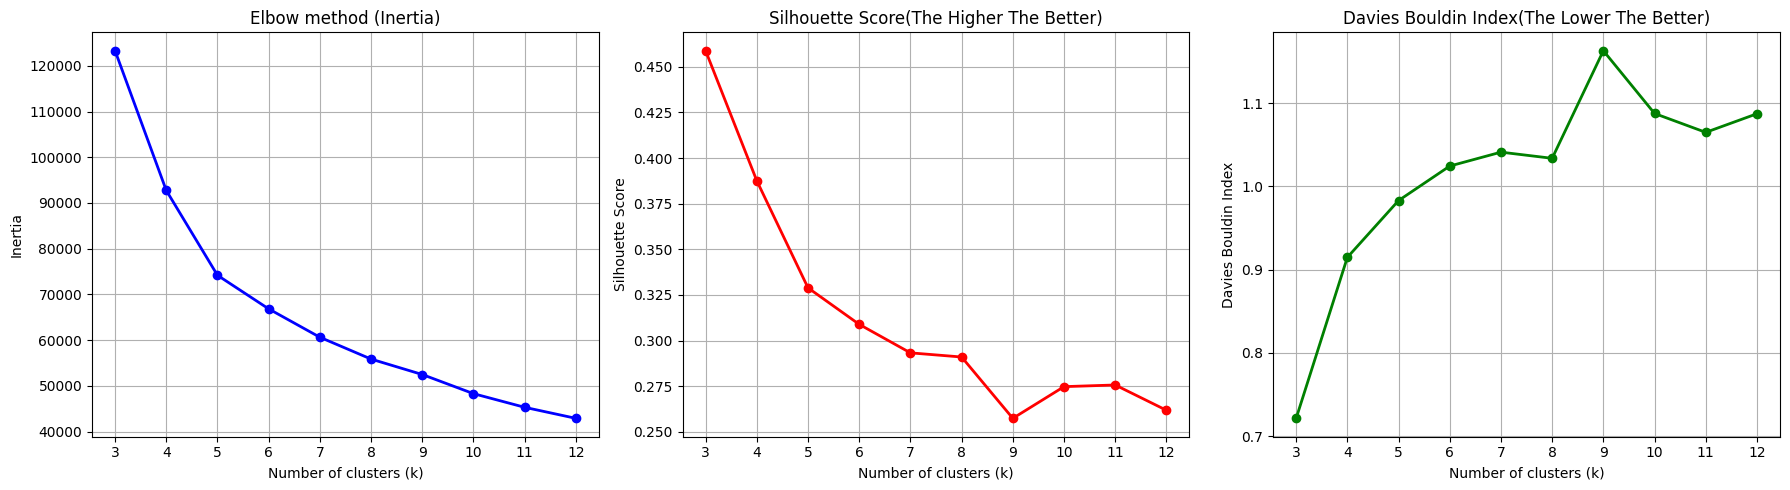

In [52]:
fig, axes  = plt.subplots(1, 3, figsize=(18, 5))
#1. ---Elbow curve----
axes[0].plot(k_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow method (Inertia)')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_range)
axes[0].grid(True)

#2. -----Silhouette score----
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2)
axes[1].set_title('Silhouette Score(The Higher The Better)')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_range)
axes[1].grid(True)

#3. ----Davies Bouldin Index----
axes[2].plot(k_range, db_scores, 'go-', linewidth=2)
axes[2].set_title('Davies Bouldin Index(The Lower The Better)')
axes[2].set_xlabel('Number of clusters (k)')
axes[2].set_ylabel('Davies Bouldin Index')
axes[2].set_xticks(k_range)
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [53]:
df_cluster = new_df.copy()


In [54]:
for k in [3, 4]:
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = km.fit_predict(new_X_scaled)
  df_cluster[f'cluster_k{k}'] = labels

In [55]:
df_cluster

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,5.88,4.55,0.00,good,striking,down,-41.4,0,0,0
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.00,10.00,0.00,good,page_3_5,down,-57.7,0,0,0
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.00,28.57,0.00,good,page_3_5,down,-60.9,0,0,0
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,2902.0,NaN,...,1.28,3.45,0.00,good,page_1,stable,-13.8,1,0,0
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.00,24.29,0.00,good,page_3_5,down,-34.7,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,content_c322796023c8,client_e29c9c180c,10.0,0.05,LOW,0.00,keyword article,transactional,1386.0,9084.0,...,0.00,0.00,0.00,low,top_3,new,NaN,0,1,1
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,0.00,66.67,0.00,moderate,page_1,down,-75.1,0,0,0
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,0.00,0.00,0.00,good,page_1,down,-66.2,0,0,0
29998,content_ab26273a7e7a,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,transactional,2902.0,NaN,...,1.73,4.06,0.00,excellent,page_1,down,-27.9,1,0,0


In [56]:
print(df_cluster.groupby('cluster_k3')[new_features].mean().round(2))
print(df_cluster.groupby('cluster_k4')[new_features].mean().round(2))

            impressions_90d  clicks_90d    ctr  word_count  search_volume  \
cluster_k3                                                                  
0                   6048.36       18.65   0.22     3384.80         160.99   
1                   1044.73        3.05   0.12     1374.15          69.04   
2                     91.28        4.92  16.38     1572.44          79.84   

            old_with_missing_values  
cluster_k3                           
0                              0.31  
1                              0.01  
2                              0.13  
            impressions_90d  clicks_90d    ctr  word_count  search_volume  \
cluster_k4                                                                  
0                   5483.50       17.52   0.22     2917.93         191.19   
1                    940.52        2.44   0.12     1365.41          66.74   
2                     91.51        4.94  16.47     1565.06          79.84   
3                   8393.85       23.63

In [57]:
df_cluster_k3_sample_1 = df_cluster.loc[df_cluster['cluster_k3'] == 0]
df_cluster_k3_sample_2 = df_cluster[df_cluster['cluster_k3']==1]
df_cluster_k3_sample_3 = df_cluster[df_cluster['cluster_k3']==2]

df_cluster_k4_sample_1 = df_cluster.loc[df_cluster['cluster_k4'] == 0]
df_cluster_k4_sample_2 = df_cluster[df_cluster['cluster_k4']==1]
df_cluster_k4_sample_3 = df_cluster[df_cluster['cluster_k4']==2]
df_cluster_k4_sample_4 = df_cluster[df_cluster['cluster_k4']==3]

In [58]:
df_cluster_k3_sample_1

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,5.88,4.55,0.00,good,striking,down,-41.4,0,0,0
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.00,10.00,0.00,good,page_3_5,down,-57.7,0,0,0
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.00,28.57,0.00,good,page_3_5,down,-60.9,0,0,0
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,2902.0,NaN,...,1.28,3.45,0.00,good,page_1,stable,-13.8,1,0,0
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.00,24.29,0.00,good,page_3_5,down,-34.7,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,content_995627a1f490,client_7f2253d7e2,70.0,0.05,LOW,0.00,keyword article,transactional,2801.0,18452.0,...,0.00,16.67,0.00,moderate,page_1,down,-65.8,0,0,0
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,0.00,66.67,0.00,moderate,page_1,down,-75.1,0,0,0
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,0.00,0.00,0.00,good,page_1,down,-66.2,0,0,0
29998,content_ab26273a7e7a,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,transactional,2902.0,NaN,...,1.73,4.06,0.00,excellent,page_1,down,-27.9,1,0,0


In [59]:
df_cluster_k3_sample_2

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
11,content_5a3e876cf7f7,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,776.0,5527.0,...,0.00,0.00,0.0,low,top_3,new,NaN,0,1,1
13,content_a5a2fbc76336,client_8527a891e2,10.0,0.00,LOW,0.00,keyword article,informational,1342.0,8469.0,...,0.00,25.00,0.0,moderate,page_3_5,stable,10.4,0,1,1
28,content_19ad8f9bac29,client_3fdba35f04,480.0,0.58,MEDIUM,1.97,keyword article,informational,1372.0,9052.0,...,0.00,58.33,0.0,moderate,deep,down,-60.0,0,1,1
29,content_ba8e51f13800,client_d59eced1de,10.0,0.00,LOW,0.00,keyword article,transactional,1626.0,11107.0,...,7.14,5.45,0.0,low,striking,new,NaN,0,1,1
40,content_4df0b7207fe3,client_9f14025af0,10.0,0.00,LOW,0.00,keyword article,transactional,896.0,6300.0,...,16.13,18.18,0.0,moderate,page_3_5,up,197.7,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29981,content_2dfd17269502,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,794.0,5776.0,...,0.00,100.00,0.0,low,striking,flat,NaN,0,1,1
29987,content_7b36d6ffe9bd,client_3fdba35f04,10.0,0.80,HIGH,0.00,keyword article,commercial,1596.0,10341.0,...,0.00,16.67,0.0,low,page_3_5,down,-61.5,0,1,1
29988,content_9bb9a0584cae,client_8527a891e2,210.0,0.00,LOW,0.00,keyword article,informational,1446.0,9001.0,...,0.00,0.00,0.0,low,deep,down,-100.0,0,1,1
29992,content_23dce6a656e6,client_e29c9c180c,140.0,0.99,HIGH,0.22,keyword article,informational,1508.0,9735.0,...,0.00,0.00,0.0,low,top_3,new,NaN,0,1,1


In [60]:
df_cluster_k3_sample_3

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
15,content_689414059706,client_9f14025af0,0.0,0.00,LOW,0.00,keyword article,informational,2661.0,17889.0,...,33.33,26.67,0.00,low,page_1,up,675.0,0,2,2
60,content_b9104a222d01,client_f369cb89fc,30.0,0.85,HIGH,0.29,keyword article,transactional,2492.0,14794.0,...,0.00,0.00,0.00,low,page_1,down,-33.3,0,2,2
61,content_d99c66ea5462,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,2661.0,19828.0,...,0.00,0.00,0.00,low,top_3,new,NaN,0,2,2
91,content_48724397d104,client_d4735e3a26,10.0,NaN,NaN,NaN,keyword article,NaN,770.0,5452.0,...,0.00,50.00,0.00,low,top_3,down,-66.7,1,2,2
113,content_824ddd97c0ae,client_bbb965ab0c,0.0,0.00,LOW,0.00,keyword article,informational,2640.0,19360.0,...,0.00,0.00,0.00,low,page_1,down,-37.5,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29566,content_09f654d4117a,client_f369cb89fc,0.0,0.00,NaN,0.00,keyword article,NaN,2625.0,19309.0,...,0.00,66.67,0.00,low,page_3_5,down,-63.2,0,2,2
29647,content_20785f2562c4,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,970.0,6533.0,...,0.00,0.00,0.00,low,page_1,new,NaN,0,2,2
29656,content_5ace8eec26ba,client_f369cb89fc,0.0,0.00,LOW,0.00,keyword article,informational,2714.0,24863.0,...,0.00,0.00,33.33,low,page_1,up,33.3,0,2,2
29862,content_aef5bb94556b,client_f369cb89fc,0.0,0.00,LOW,0.00,keyword article,informational,2986.0,17339.0,...,0.00,0.00,0.00,low,page_3_5,flat,NaN,0,2,2


In [61]:
df_cluster_k4_sample_1.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
count,20176.000000,19716.000000,19716.000000,20176.000000,12517.000000,20176.000000,20176.000000,20176.000000,20176.000000,20176.000000,...,20176.000000,20176.000000,20176.000000,20176.000000,20058.000000,20176.000000,18908.000000,20176.000000,20176.000000,20176.0
mean,191.194984,0.156784,0.477686,2917.929818,19521.649517,5483.502429,17.519082,35.146511,29.086836,27.933188,...,36.751784,0.223236,16.129307,2.694645,16.700853,0.616687,1.574170,0.384120,0.003420,0.0
std,1692.741631,0.292820,1.945325,306.569143,4973.009156,17536.525713,81.146654,114.594606,91.877837,88.683144,...,36.229017,0.372122,14.779428,8.066157,29.052732,6.597705,546.475354,0.486398,0.061684,0.0
min,0.000000,0.000000,0.000000,1725.000000,10971.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,0.000000,2788.000000,17335.000000,165.000000,0.000000,2.000000,2.000000,2.000000,...,20.000000,0.000000,6.400000,0.000000,0.000000,0.000000,-58.725000,0.000000,0.000000,0.0
50%,10.000000,0.000000,0.000000,2902.000000,19059.000000,901.500000,1.000000,8.000000,7.000000,7.000000,...,20.000000,0.090000,10.200000,0.000000,4.110000,0.000000,-29.400000,0.000000,0.000000,0.0
75%,30.000000,0.140000,0.050000,2963.000000,21068.000000,3892.250000,8.000000,27.000000,24.000000,23.000000,...,25.000000,0.290000,21.100000,1.830000,20.000000,0.000000,3.600000,1.000000,0.000000,0.0
max,74000.000000,1.000000,60.130000,4182.000000,111158.000000,517715.000000,4178.000000,4912.000000,4345.000000,4913.000000,...,373.000000,3.850000,98.600000,100.000000,300.000000,233.330000,44900.000000,1.000000,2.000000,0.0


In [62]:
df_cluster_k4_sample_2.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
count,4353.000000,3202.000000,3202.000000,4353.000000,4353.000000,4353.000000,4353.000000,4353.000000,4353.000000,4353.000000,...,4353.000000,4353.000000,4353.000000,4353.000000,4351.000000,4353.000000,2950.000000,4353.000000,4353.0,4353.0
mean,66.744774,0.231630,0.920153,1365.411900,8957.913853,940.518723,2.438548,12.583965,10.142890,9.875258,...,60.597749,0.115626,16.286745,2.340806,26.040832,0.983223,-24.043051,0.013784,1.0,1.0
std,532.123023,0.333196,3.356646,284.294582,1673.377866,4175.820245,15.167901,31.254285,23.545087,22.247456,...,46.632029,0.294781,19.096092,9.141100,33.392693,9.211521,254.889600,0.116605,0.0,0.0
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.000000,1.0,1.0
25%,0.000000,0.000000,0.000000,1248.000000,8189.000000,3.000000,0.000000,1.000000,1.000000,1.000000,...,20.000000,0.000000,4.000000,0.000000,0.000000,0.000000,-82.600000,0.000000,1.0,1.0
50%,10.000000,0.030000,0.000000,1420.000000,9172.000000,61.000000,0.000000,3.000000,3.000000,3.000000,...,20.000000,0.000000,9.000000,0.000000,13.040000,0.000000,-57.250000,0.000000,1.0,1.0
75%,20.000000,0.410000,0.260000,1547.000000,10031.000000,682.000000,1.000000,12.000000,9.000000,9.000000,...,104.000000,0.090000,22.700000,0.000000,36.940000,0.000000,-16.700000,0.000000,1.0,1.0
max,22200.000000,1.000000,100.360000,2066.000000,13815.000000,130932.000000,522.000000,737.000000,473.000000,451.000000,...,334.000000,2.630000,245.000000,100.000000,200.000000,200.000000,11266.700000,1.000000,1.0,1.0


In [63]:
df_cluster_k4_sample_3.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
count,559.000000,199.000000,199.000000,559.000000,519.00000,559.000000,559.000000,559.000000,559.000000,559.000000,...,559.000000,559.000000,559.000000,559.000000,558.000000,559.000000,410.000000,559.000000,559.0,559.0
mean,79.838998,0.106784,0.616583,1565.060823,10223.00578,91.506261,4.944544,6.778175,6.042934,5.729875,...,36.579606,16.470984,8.127191,8.117102,28.605627,1.558354,36.117805,0.130590,2.0,2.0
std,1414.975389,0.272893,4.012902,997.231487,6576.77547,1205.697900,57.462677,69.799412,61.571868,57.044317,...,53.143753,17.632203,10.396640,23.577570,37.837514,11.777574,166.210887,0.337254,0.0,0.0
min,0.000000,0.000000,0.000000,588.000000,4129.00000,1.000000,1.000000,0.000000,1.000000,1.000000,...,1.000000,2.800000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.000000,2.0,2.0
25%,0.000000,0.000000,0.000000,826.500000,5905.00000,6.000000,1.000000,1.000000,1.000000,1.000000,...,20.000000,5.280000,3.500000,0.000000,0.000000,0.000000,-50.000000,0.000000,2.0,2.0
50%,0.000000,0.000000,0.000000,946.000000,6621.00000,13.000000,1.000000,2.000000,2.000000,1.000000,...,20.000000,9.090000,5.300000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,2.0
75%,0.000000,0.000000,0.000000,2667.000000,15759.00000,25.000000,2.000000,4.000000,3.000000,3.000000,...,20.000000,20.000000,8.150000,0.000000,50.000000,0.000000,66.700000,0.000000,2.0,2.0
max,33100.000000,1.000000,53.510000,5747.000000,41336.00000,28192.000000,1347.000000,1638.000000,1444.000000,1337.000000,...,373.000000,100.000000,98.000000,100.000000,150.000000,200.000000,1800.000000,1.000000,2.0,2.0


In [64]:
df_cluster_k4_sample_4.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
count,4912.000000,4415.000000,4415.000000,4912.000000,4912.000000,4912.000000,4912.000000,4912.000000,4912.000000,4912.000000,...,4912.000000,4912.000000,4912.000000,4912.000000,4908.000000,4912.000000,4344.000000,4912.000000,4912.0,4912.0
mean,37.734121,0.043456,0.198267,5284.609528,35057.885790,8393.854642,23.631107,148.735953,97.233917,95.350366,...,72.722923,0.225446,18.201792,1.413164,16.271335,1.110041,-23.252739,0.000611,0.0,3.0
std,811.257045,0.155663,1.237233,1106.669229,7142.194006,20574.517979,80.970968,271.739695,172.602282,167.729104,...,43.718384,0.399668,13.050954,3.521317,24.648686,8.189513,167.707793,0.024708,0.0,0.0
min,0.000000,0.000000,0.000000,3698.000000,22483.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.000000,0.0,3.0
25%,0.000000,0.000000,0.000000,4292.750000,29309.750000,138.000000,0.000000,10.000000,8.000000,8.000000,...,20.000000,0.000000,8.600000,0.000000,2.000000,0.000000,-61.700000,0.000000,0.0,3.0
50%,0.000000,0.000000,0.000000,5152.000000,34216.000000,2063.500000,2.000000,50.000000,34.500000,34.000000,...,104.000000,0.080000,16.200000,0.000000,5.710000,0.000000,-38.700000,0.000000,0.0,3.0
75%,0.000000,0.000000,0.000000,6083.250000,40005.000000,8523.250000,17.000000,182.000000,119.000000,117.000000,...,104.000000,0.280000,25.600000,1.750000,20.830000,0.000000,-11.800000,0.000000,0.0,3.0
max,40500.000000,1.000000,22.050000,9546.000000,111074.000000,497727.000000,2653.000000,5998.000000,4218.000000,4153.000000,...,304.000000,5.560000,165.500000,100.000000,200.000000,300.000000,5850.000000,1.000000,0.0,3.0


In [65]:
cond = df_cluster_k4_sample_1.loc[df_cluster_k4_sample_1['content_type']=='feedly article']
sample_9 = cond
sample_9

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
263,content_f54906da38ee,client_25fc0e7096,0.0,NaN,NaN,NaN,feedly article,NaN,3686.0,26356.0,...,0.0,20.83,0.0,low,top_3,new,NaN,0,0,0
373,content_708a4c3cb9b1,client_624b60c58c,0.0,NaN,NaN,NaN,feedly article,NaN,3718.0,26474.0,...,0.0,50.00,0.0,low,striking,down,-100.0,0,0,0
655,content_afaea9f24786,client_624b60c58c,0.0,NaN,NaN,NaN,feedly article,NaN,3696.0,24471.0,...,0.0,100.00,0.0,low,striking,stable,0.0,0,0,0
764,content_523083f6f852,client_624b60c58c,0.0,NaN,NaN,NaN,feedly article,NaN,3636.0,24489.0,...,0.0,85.00,5.0,low,page_1,down,-70.4,0,0,0
888,content_cf5ba999d252,client_25fc0e7096,0.0,NaN,NaN,NaN,feedly article,NaN,3754.0,26748.0,...,0.0,20.83,0.0,low,top_3,new,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29437,content_5d7fa6c841f9,client_624b60c58c,0.0,NaN,NaN,NaN,feedly article,NaN,3699.0,24423.0,...,0.0,50.00,0.0,low,striking,down,-100.0,0,0,0
29771,content_a214c0c380c5,client_25fc0e7096,0.0,NaN,NaN,NaN,feedly article,NaN,3817.0,26805.0,...,0.0,20.83,0.0,low,top_3,new,NaN,0,0,0
29864,content_d10c7372129c,client_624b60c58c,0.0,NaN,NaN,NaN,feedly article,NaN,3542.0,25258.0,...,0.0,66.67,0.0,low,page_1,down,-88.2,0,0,0
29899,content_1d4f4025c930,client_25fc0e7096,0.0,NaN,NaN,NaN,feedly article,NaN,3510.0,24432.0,...,0.0,20.83,0.0,low,top_3,new,NaN,0,0,0


In [66]:
sample_9.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
count,187.0,0.0,0.0,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,...,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,76.000000,187.0,187.000000,187.0
mean,0.0,NaN,NaN,3519.048128,25036.951872,268.219251,0.893048,14.962567,13.983957,13.930481,...,21.016043,0.106738,4.439037,0.172032,33.780749,2.551872,-40.782895,0.0,0.005348,0.0
std,0.0,NaN,NaN,337.473938,2273.420277,1533.746075,4.968644,13.543387,12.850453,12.727942,...,30.138297,0.460881,6.106750,1.085602,28.683523,12.730128,91.588799,0.0,0.073127,0.0
min,0.0,NaN,NaN,2110.000000,16625.000000,1.000000,0.000000,1.000000,1.000000,1.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.0,0.000000,0.0
25%,0.0,NaN,NaN,3433.500000,24122.500000,3.000000,0.000000,2.000000,2.000000,2.000000,...,8.000000,0.000000,0.000000,0.000000,20.830000,0.000000,-100.000000,0.0,0.000000,0.0
50%,0.0,NaN,NaN,3636.000000,25383.000000,3.000000,0.000000,20.000000,20.000000,20.000000,...,8.000000,0.000000,3.300000,0.000000,20.830000,0.000000,-72.700000,0.0,0.000000,0.0
75%,0.0,NaN,NaN,3736.000000,26531.500000,38.500000,0.000000,24.000000,22.000000,22.000000,...,20.000000,0.000000,7.300000,0.000000,50.000000,0.000000,-3.650000,0.0,0.000000,0.0
max,0.0,NaN,NaN,3839.000000,29729.000000,15673.000000,56.000000,97.000000,97.000000,95.000000,...,105.000000,3.700000,42.600000,10.000000,100.000000,100.000000,440.000000,0.0,1.000000,0.0


In [67]:
sample_10 = df_cluster_k4_sample_1.loc[df_cluster_k4_sample_1['content_type']=='keyword article']
sample_10

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,5.88,4.55,0.0,good,striking,down,-41.4,0,0,0
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.00,10.00,0.0,good,page_3_5,down,-57.7,0,0,0
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.00,28.57,0.0,good,page_3_5,down,-60.9,0,0,0
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,2902.0,NaN,...,1.28,3.45,0.0,good,page_1,stable,-13.8,1,0,0
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.00,24.29,0.0,good,page_3_5,down,-34.7,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29993,content_9bd30342fd4a,client_19581e27de,70.0,0.95,HIGH,0.34,keyword article,transactional,2902.0,NaN,...,0.00,0.00,0.0,moderate,page_3_5,stable,0.0,1,0,0
29994,content_995627a1f490,client_7f2253d7e2,70.0,0.05,LOW,0.00,keyword article,transactional,2801.0,18452.0,...,0.00,16.67,0.0,moderate,page_1,down,-65.8,0,0,0
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,0.00,66.67,0.0,moderate,page_1,down,-75.1,0,0,0
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,0.00,0.00,0.0,good,page_1,down,-66.2,0,0,0


In [68]:
sample_10.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
count,19544.000000,19271.000000,19271.000000,19544.000000,11885.000000,19544.000000,19544.000000,19544.000000,19544.000000,19544.000000,...,19544.000000,19544.000000,19544.000000,19544.000000,19428.000000,19544.000000,18389.000000,19544.000000,19544.000000,19544.0
mean,197.377712,0.160405,0.488717,2915.147309,19456.473286,5650.729943,18.070917,36.059916,29.818000,28.627712,...,37.356836,0.227028,16.367044,2.770500,15.440042,0.606620,2.071831,0.396541,0.003121,0.0
std,1719.539768,0.295199,1.966288,294.748297,4996.177539,17791.692571,82.387786,116.306375,93.247093,90.006857,...,36.522497,0.371455,14.889088,8.145525,27.524791,6.570124,553.923895,0.489192,0.059337,0.0
min,0.000000,0.000000,0.000000,1725.000000,10971.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,0.000000,2797.000000,17351.000000,187.000000,0.000000,3.000000,2.000000,2.000000,...,20.000000,0.000000,6.400000,0.000000,0.000000,0.000000,-58.800000,0.000000,0.000000,0.0
50%,10.000000,0.000000,0.000000,2902.000000,19044.000000,986.000000,1.000000,8.000000,8.000000,7.000000,...,20.000000,0.100000,10.400000,0.000000,3.700000,0.000000,-29.300000,0.000000,0.000000,0.0
75%,30.000000,0.160000,0.060000,2951.000000,20967.000000,4081.500000,8.000000,28.000000,25.000000,24.000000,...,25.000000,0.300000,21.400000,2.070000,17.650000,0.000000,3.800000,1.000000,0.000000,0.0
max,74000.000000,1.000000,60.130000,4182.000000,111158.000000,517715.000000,4178.000000,4912.000000,4345.000000,4913.000000,...,373.000000,3.850000,98.600000,100.000000,300.000000,233.330000,44900.000000,1.000000,2.000000,0.0


In [69]:
sample_11 = df_cluster_k4_sample_2.loc[df_cluster_k4_sample_2['content_type']=='feedly article']
sample_11

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
11,content_5a3e876cf7f7,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,776.0,5527.0,...,0.0,0.00,0.0,low,top_3,new,NaN,0,1,1
71,content_ced59bb3a1a6,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,1199.0,9050.0,...,0.0,0.00,0.0,low,top_3,stable,0.0,0,1,1
146,content_68a5aeeed6e4,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,854.0,6152.0,...,0.0,0.00,0.0,low,top_3,flat,NaN,0,1,1
212,content_4887e1fcbe25,client_25fc0e7096,0.0,NaN,NaN,NaN,feedly article,NaN,1491.0,10196.0,...,0.0,20.83,0.0,low,top_3,new,NaN,0,1,1
259,content_da5ef9f70786,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,764.0,5277.0,...,0.0,100.00,0.0,low,top_3,new,NaN,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29773,content_4f11749a1306,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,796.0,5508.0,...,0.0,0.00,0.0,low,top_3,new,NaN,0,1,1
29807,content_ca9647344fa0,client_4ec9599fc2,0.0,NaN,NaN,NaN,feedly article,NaN,1306.0,9732.0,...,0.0,0.00,0.0,low,page_1,down,-23.0,0,1,1
29831,content_ba7082c9436c,client_25fc0e7096,0.0,NaN,NaN,NaN,feedly article,NaN,1383.0,10020.0,...,0.0,24.00,0.0,low,top_3,new,NaN,0,1,1
29973,content_4be930227848,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,730.0,5475.0,...,0.0,100.00,0.0,low,page_1,stable,0.0,0,1,1


In [70]:
sample_11.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
count,1091.0,0.0,0.0,1091.000000,1091.000000,1091.000000,1091.000000,1091.000000,1091.000000,1091.000000,...,1091.000000,1091.000000,1091.000000,1091.000000,1090.000000,1091.000000,540.000000,1091.0,1091.0,1091.0
mean,0.0,NaN,NaN,1062.981668,7575.371219,198.479377,0.751604,6.281393,5.945005,5.892759,...,33.497709,0.134794,6.942438,1.211100,44.620092,1.912154,3.177222,0.0,1.0,1.0
std,0.0,NaN,NaN,288.639173,2002.058525,809.805887,4.502770,14.729070,13.747417,13.418270,...,32.610050,0.415185,10.133447,8.668086,42.903842,14.435163,225.434981,0.0,0.0,0.0
min,0.0,NaN,NaN,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.0,1.0,1.0
25%,0.0,NaN,NaN,823.000000,5933.500000,2.000000,0.000000,1.000000,1.000000,1.000000,...,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-78.600000,0.0,1.0,1.0
50%,0.0,NaN,NaN,955.000000,6872.000000,4.000000,0.000000,2.000000,2.000000,2.000000,...,20.000000,0.000000,4.500000,0.000000,33.330000,0.000000,-42.800000,0.0,1.0,1.0
75%,0.0,NaN,NaN,1298.000000,9181.000000,49.000000,0.000000,5.000000,4.000000,4.000000,...,20.000000,0.000000,8.100000,0.000000,100.000000,0.000000,0.000000,0.0,1.0,1.0
max,0.0,NaN,NaN,1930.000000,13401.000000,11830.000000,115.000000,326.000000,298.000000,286.000000,...,104.000000,2.630000,69.100000,100.000000,200.000000,200.000000,3200.000000,0.0,1.0,1.0


In [71]:
sample_12 = df_cluster_k4_sample_2.loc[df_cluster_k4_sample_2['content_type']=='keyword article']
sample_12

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
13,content_a5a2fbc76336,client_8527a891e2,10.0,0.00,LOW,0.00,keyword article,informational,1342.0,8469.0,...,0.00,25.00,0.0,moderate,page_3_5,stable,10.4,0,1,1
28,content_19ad8f9bac29,client_3fdba35f04,480.0,0.58,MEDIUM,1.97,keyword article,informational,1372.0,9052.0,...,0.00,58.33,0.0,moderate,deep,down,-60.0,0,1,1
29,content_ba8e51f13800,client_d59eced1de,10.0,0.00,LOW,0.00,keyword article,transactional,1626.0,11107.0,...,7.14,5.45,0.0,low,striking,new,NaN,0,1,1
40,content_4df0b7207fe3,client_9f14025af0,10.0,0.00,LOW,0.00,keyword article,transactional,896.0,6300.0,...,16.13,18.18,0.0,moderate,page_3_5,up,197.7,0,1,1
49,content_f0717373e86e,client_8527a891e2,0.0,0.00,LOW,0.00,keyword article,informational,1585.0,10113.0,...,0.00,100.00,0.0,low,striking,down,-100.0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29974,content_b00f10211e25,client_3fdba35f04,70.0,0.99,HIGH,3.24,keyword article,informational,1371.0,8795.0,...,0.00,13.04,0.0,moderate,page_3_5,down,-56.3,0,1,1
29987,content_7b36d6ffe9bd,client_3fdba35f04,10.0,0.80,HIGH,0.00,keyword article,commercial,1596.0,10341.0,...,0.00,16.67,0.0,low,page_3_5,down,-61.5,0,1,1
29988,content_9bb9a0584cae,client_8527a891e2,210.0,0.00,LOW,0.00,keyword article,informational,1446.0,9001.0,...,0.00,0.00,0.0,low,deep,down,-100.0,0,1,1
29992,content_23dce6a656e6,client_e29c9c180c,140.0,0.99,HIGH,0.22,keyword article,informational,1508.0,9735.0,...,0.00,0.00,0.0,low,top_3,new,NaN,0,1,1


In [72]:
sample_12.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
count,3259.000000,3199.000000,3199.000000,3259.00000,3259.000000,3259.000000,3259.000000,3259.000000,3259.000000,3259.000000,...,3259.000000,3259.000000,3259.000000,3259.000000,3258.000000,3259.000000,2407.000000,3259.000000,3259.0,3259.0
mean,89.150046,0.231847,0.921016,1466.06413,9416.519791,1189.660632,3.005523,14.702976,11.555078,11.215097,...,69.714636,0.109316,19.416662,2.721148,19.796734,0.673154,-30.217781,0.018411,1.0,1.0
std,613.381710,0.333277,3.358102,197.35242,1236.780005,4777.690029,17.298998,34.847825,25.871672,24.367041,...,47.092234,0.241306,20.338307,9.268415,26.784690,6.576070,260.816745,0.134451,0.0,0.0
min,0.000000,0.000000,0.000000,424.00000,3143.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.000000,1.0,1.0
25%,10.000000,0.000000,0.000000,1361.00000,8684.000000,5.000000,0.000000,2.000000,1.000000,1.000000,...,20.000000,0.000000,5.500000,0.000000,0.000000,0.000000,-82.800000,0.000000,1.0,1.0
50%,10.000000,0.030000,0.000000,1470.00000,9404.000000,215.000000,0.000000,4.000000,3.000000,3.000000,...,103.000000,0.000000,12.400000,0.000000,10.000000,0.000000,-60.000000,0.000000,1.0,1.0
75%,30.000000,0.415000,0.270000,1582.00000,10161.500000,941.500000,1.000000,15.000000,11.000000,11.000000,...,104.000000,0.120000,27.900000,0.000000,30.000000,0.000000,-23.900000,0.000000,1.0,1.0
max,22200.000000,1.000000,100.360000,2066.00000,13815.000000,130932.000000,522.000000,737.000000,473.000000,451.000000,...,334.000000,2.500000,245.000000,100.000000,100.000000,100.000000,11266.700000,1.000000,1.0,1.0


In [73]:
df_cluster_k3_sample_1

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,5.88,4.55,0.00,good,striking,down,-41.4,0,0,0
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.00,10.00,0.00,good,page_3_5,down,-57.7,0,0,0
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.00,28.57,0.00,good,page_3_5,down,-60.9,0,0,0
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,2902.0,NaN,...,1.28,3.45,0.00,good,page_1,stable,-13.8,1,0,0
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.00,24.29,0.00,good,page_3_5,down,-34.7,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,content_995627a1f490,client_7f2253d7e2,70.0,0.05,LOW,0.00,keyword article,transactional,2801.0,18452.0,...,0.00,16.67,0.00,moderate,page_1,down,-65.8,0,0,0
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,0.00,66.67,0.00,moderate,page_1,down,-75.1,0,0,0
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,0.00,0.00,0.00,good,page_1,down,-66.2,0,0,0
29998,content_ab26273a7e7a,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,transactional,2902.0,NaN,...,1.73,4.06,0.00,excellent,page_1,down,-27.9,1,0,0


In [74]:
df_cluster_k3_sample_1.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
count,25023.000000,24067.000000,24067.000000,25023.000000,17364.000000,25023.000000,25023.000000,25023.000000,25023.000000,25023.000000,...,25023.000000,25023.000000,25023.000000,25023.000000,24901.000000,25023.000000,23194.000000,25023.000000,25023.0,25023.000000
mean,160.987092,0.135816,0.426045,3384.800344,23928.911023,6048.361467,18.650202,57.378971,42.407465,41.113655,...,43.763018,0.222888,16.532750,2.440410,16.602778,0.712241,-3.028417,0.309835,0.0,0.588898
std,1561.236644,0.276183,1.839962,1093.439161,8954.253187,18183.763031,80.556778,164.191739,115.231305,111.721667,...,40.404062,0.375189,14.476951,7.413185,28.238172,6.944826,498.802518,0.462435,0.0,1.191617
min,0.000000,0.000000,0.000000,1957.000000,12590.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.000000,0.0,0.000000
25%,0.000000,0.000000,0.000000,2875.000000,18026.000000,163.000000,0.000000,3.000000,3.000000,3.000000,...,20.000000,0.000000,6.600000,0.000000,0.000000,0.000000,-59.600000,0.000000,0.0,0.000000
50%,10.000000,0.000000,0.000000,2902.000000,20563.000000,1034.000000,1.000000,11.000000,9.000000,9.000000,...,20.000000,0.090000,11.200000,0.000000,4.550000,0.000000,-31.500000,0.000000,0.0,0.000000
75%,20.000000,0.100000,0.000000,3504.000000,27242.250000,4678.000000,9.000000,41.000000,33.000000,32.000000,...,104.000000,0.290000,22.500000,1.790000,20.000000,0.000000,0.075000,1.000000,0.0,0.000000
max,74000.000000,1.000000,60.130000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,...,373.000000,5.560000,165.500000,100.000000,300.000000,300.000000,44900.000000,1.000000,0.0,3.000000


In [75]:
df_cluster_k3_sample_2

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
11,content_5a3e876cf7f7,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,776.0,5527.0,...,0.00,0.00,0.0,low,top_3,new,NaN,0,1,1
13,content_a5a2fbc76336,client_8527a891e2,10.0,0.00,LOW,0.00,keyword article,informational,1342.0,8469.0,...,0.00,25.00,0.0,moderate,page_3_5,stable,10.4,0,1,1
28,content_19ad8f9bac29,client_3fdba35f04,480.0,0.58,MEDIUM,1.97,keyword article,informational,1372.0,9052.0,...,0.00,58.33,0.0,moderate,deep,down,-60.0,0,1,1
29,content_ba8e51f13800,client_d59eced1de,10.0,0.00,LOW,0.00,keyword article,transactional,1626.0,11107.0,...,7.14,5.45,0.0,low,striking,new,NaN,0,1,1
40,content_4df0b7207fe3,client_9f14025af0,10.0,0.00,LOW,0.00,keyword article,transactional,896.0,6300.0,...,16.13,18.18,0.0,moderate,page_3_5,up,197.7,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29981,content_2dfd17269502,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,794.0,5776.0,...,0.00,100.00,0.0,low,striking,flat,NaN,0,1,1
29987,content_7b36d6ffe9bd,client_3fdba35f04,10.0,0.80,HIGH,0.00,keyword article,commercial,1596.0,10341.0,...,0.00,16.67,0.0,low,page_3_5,down,-61.5,0,1,1
29988,content_9bb9a0584cae,client_8527a891e2,210.0,0.00,LOW,0.00,keyword article,informational,1446.0,9001.0,...,0.00,0.00,0.0,low,deep,down,-100.0,0,1,1
29992,content_23dce6a656e6,client_e29c9c180c,140.0,0.99,HIGH,0.22,keyword article,informational,1508.0,9735.0,...,0.00,0.00,0.0,low,top_3,new,NaN,0,1,1


In [76]:
df_cluster_k3_sample_3

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
15,content_689414059706,client_9f14025af0,0.0,0.00,LOW,0.00,keyword article,informational,2661.0,17889.0,...,33.33,26.67,0.00,low,page_1,up,675.0,0,2,2
60,content_b9104a222d01,client_f369cb89fc,30.0,0.85,HIGH,0.29,keyword article,transactional,2492.0,14794.0,...,0.00,0.00,0.00,low,page_1,down,-33.3,0,2,2
61,content_d99c66ea5462,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,2661.0,19828.0,...,0.00,0.00,0.00,low,top_3,new,NaN,0,2,2
91,content_48724397d104,client_d4735e3a26,10.0,NaN,NaN,NaN,keyword article,NaN,770.0,5452.0,...,0.00,50.00,0.00,low,top_3,down,-66.7,1,2,2
113,content_824ddd97c0ae,client_bbb965ab0c,0.0,0.00,LOW,0.00,keyword article,informational,2640.0,19360.0,...,0.00,0.00,0.00,low,page_1,down,-37.5,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29566,content_09f654d4117a,client_f369cb89fc,0.0,0.00,NaN,0.00,keyword article,NaN,2625.0,19309.0,...,0.00,66.67,0.00,low,page_3_5,down,-63.2,0,2,2
29647,content_20785f2562c4,client_d4735e3a26,0.0,NaN,NaN,NaN,feedly article,NaN,970.0,6533.0,...,0.00,0.00,0.00,low,page_1,new,NaN,0,2,2
29656,content_5ace8eec26ba,client_f369cb89fc,0.0,0.00,LOW,0.00,keyword article,informational,2714.0,24863.0,...,0.00,0.00,33.33,low,page_1,up,33.3,0,2,2
29862,content_aef5bb94556b,client_f369cb89fc,0.0,0.00,LOW,0.00,keyword article,informational,2986.0,17339.0,...,0.00,0.00,0.00,low,page_3_5,flat,NaN,0,2,2


In [77]:
df_cluster_k3_sample_3.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,old_with_missing_values,cluster_k3,cluster_k4
count,563.000000,203.000000,203.000000,563.000000,523.000000,563.000000,563.000000,563.000000,563.000000,563.000000,...,563.000000,563.000000,563.000000,563.000000,562.000000,563.000000,414.000000,563.000000,563.0,563.000000
mean,79.840142,0.109606,0.609360,1572.436945,10292.879541,91.280639,4.923623,6.747780,6.019538,5.708703,...,36.476021,16.377602,8.185435,8.059432,28.668932,1.606483,35.148068,0.129663,2.0,1.985790
std,1409.979358,0.277681,3.973767,997.507529,6605.359808,1201.406206,57.258447,69.551617,61.353111,56.841639,...,52.969279,17.604052,10.475669,23.503422,37.871947,11.812315,165.705571,0.336231,0.0,0.168129
min,0.000000,0.000000,0.000000,588.000000,4129.000000,1.000000,1.000000,0.000000,1.000000,1.000000,...,1.000000,2.800000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.000000,2.0,0.000000
25%,0.000000,0.000000,0.000000,827.000000,5927.500000,6.000000,1.000000,1.000000,1.000000,1.000000,...,20.000000,5.260000,3.500000,0.000000,0.000000,0.000000,-50.000000,0.000000,2.0,2.000000
50%,0.000000,0.000000,0.000000,947.000000,6638.000000,14.000000,1.000000,2.000000,2.000000,2.000000,...,20.000000,9.090000,5.300000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,2.000000
75%,0.000000,0.000000,0.000000,2661.000000,15952.500000,25.500000,2.000000,4.000000,3.000000,3.000000,...,20.000000,20.000000,8.150000,0.000000,50.000000,0.000000,66.700000,0.000000,2.0,2.000000
max,33100.000000,1.000000,53.510000,5747.000000,41336.000000,28192.000000,1347.000000,1638.000000,1444.000000,1337.000000,...,373.000000,100.000000,98.000000,100.000000,150.000000,200.000000,1800.000000,1.000000,2.0,2.000000
